# Feature Normalization Challenge — Data Exploration

This notebook loads all parquet files and produces visualizations to understand the dataset before modeling.

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('Libraries loaded.')

Libraries loaded.


## 1. Load All Data

In [2]:
train_products  = pd.read_parquet('data/train/products.parquet')
train_features  = pd.read_parquet('data/train/product_features.parquet')
val_products    = pd.read_parquet('data/val/products.parquet')
val_features    = pd.read_parquet('data/val/product_features.parquet')
test_products   = pd.read_parquet('data/test/products.parquet')
submission      = pd.read_parquet('data/test/submission.parquet')
taxonomy        = pd.read_parquet('data/taxonomy/taxonomy.parquet')

print('All files loaded.')

All files loaded.


## 2. Dataset Overview

In [3]:
overview = pd.DataFrame([
    {'File': 'train/products',          'Rows': len(train_products),  'Columns': train_products.shape[1]},
    {'File': 'train/product_features',  'Rows': len(train_features),  'Columns': train_features.shape[1]},
    {'File': 'val/products',            'Rows': len(val_products),    'Columns': val_products.shape[1]},
    {'File': 'val/product_features',    'Rows': len(val_features),    'Columns': val_features.shape[1]},
    {'File': 'test/products',           'Rows': len(test_products),   'Columns': test_products.shape[1]},
    {'File': 'test/submission',         'Rows': len(submission),      'Columns': submission.shape[1]},
    {'File': 'taxonomy/taxonomy',       'Rows': len(taxonomy),        'Columns': taxonomy.shape[1]},
])
overview['Rows'] = overview['Rows'].map('{:,}'.format)
overview.style.set_table_styles([{'selector': 'th', 'props': [('font-weight', 'bold')]}])

,File,Rows,Columns
0,train/products,"1,425,067",4
1,train/product_features,"3,221,974",4
2,val/products,"405,965",4
3,val/product_features,"1,052,171",4
4,test/products,"3,103,603",4
5,test/submission,"7,864,744",4
6,taxonomy/taxonomy,"65,766",4


### Column schemas

In [4]:
for name, df in [('train_products', train_products), ('train_features', train_features),
                 ('taxonomy', taxonomy), ('submission', submission)]:
    print(f'--- {name} ---')
    print(df.dtypes.to_string())
    print()

--- train_products ---
uid            string[python]
category       string[python]
title          string[python]
description            object

--- train_features ---
uid              string[python]
feature_name     string[python]
feature_value            object
feature_type     string[python]

--- taxonomy ---
category                     object
feature_name                 object
aggregated_feature_values    object
feature_type                 object

--- submission ---
uid              string[python]
feature_name     string[python]
feature_value            object
feature_type     string[python]



## 3. Split Size Comparison

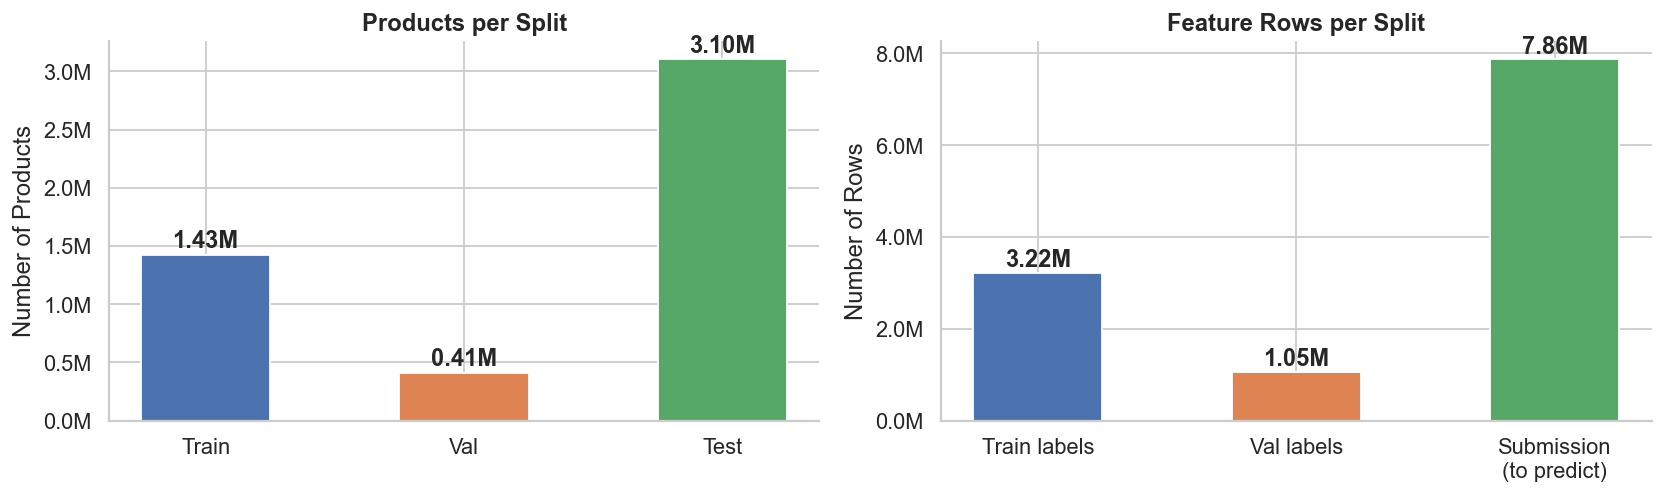

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Products per split
splits = ['Train', 'Val', 'Test']
n_products = [len(train_products), len(val_products), len(test_products)]
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = axes[0].bar(splits, n_products, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Products per Split', fontweight='bold')
axes[0].set_ylabel('Number of Products')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, n in zip(bars, n_products):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20000,
                 f'{n/1e6:.2f}M', ha='center', va='bottom', fontweight='bold')

# Feature rows per split
feat_splits = ['Train labels', 'Val labels', 'Submission\n(to predict)']
n_feats = [len(train_features), len(val_features), len(submission)]
bars2 = axes[1].bar(feat_splits, n_feats, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('Feature Rows per Split', fontweight='bold')
axes[1].set_ylabel('Number of Rows')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, n in zip(bars2, n_feats):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30000,
                 f'{n/1e6:.2f}M', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Category Distribution

Unique categories in train: 3,240
Unique categories in taxonomy: 23,357


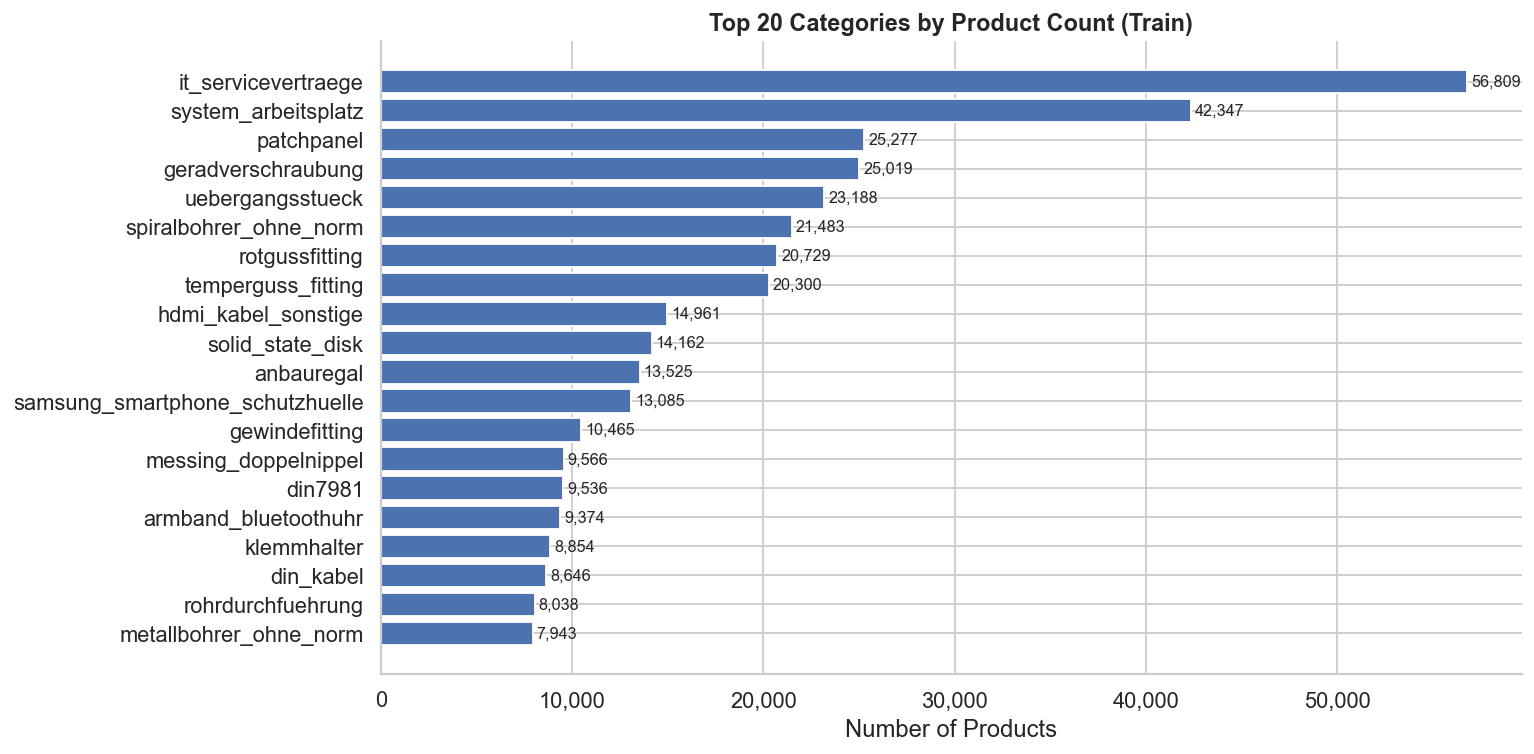

In [6]:
print(f'Unique categories in train: {train_products["category"].nunique():,}')
print(f'Unique categories in taxonomy: {taxonomy["category"].nunique():,}')

top_cats = train_products['category'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_cats.index[::-1], top_cats.values[::-1], color='#4C72B0', edgecolor='white')
ax.set_title('Top 20 Categories by Product Count (Train)', fontweight='bold', fontsize=13)
ax.set_xlabel('Number of Products')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, n in zip(bars, top_cats.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

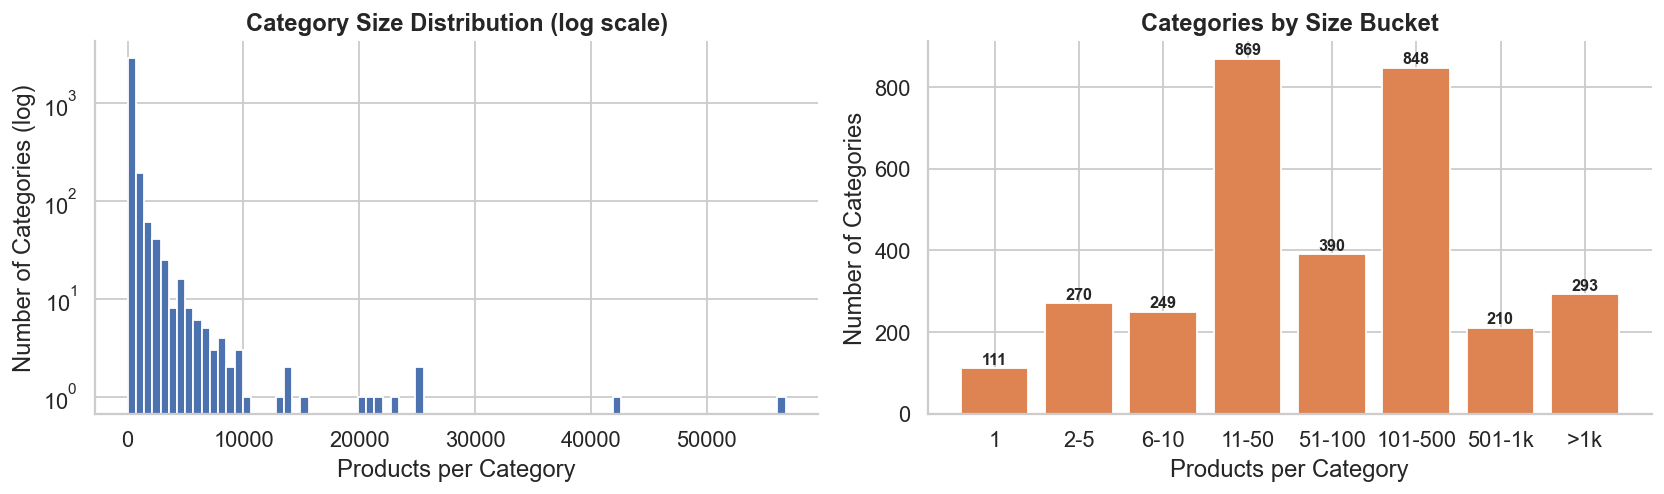

In [7]:
# Long-tail distribution
cat_counts = train_products['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(cat_counts.values, bins=80, color='#4C72B0', edgecolor='white', log=True)
axes[0].set_title('Category Size Distribution (log scale)', fontweight='bold')
axes[0].set_xlabel('Products per Category')
axes[0].set_ylabel('Number of Categories (log)')

buckets = pd.cut(cat_counts, bins=[0,1,5,10,50,100,500,1000,cat_counts.max()+1],
                 labels=['1','2-5','6-10','11-50','51-100','101-500','501-1k','>1k'])
bucket_counts = buckets.value_counts().sort_index()
axes[1].bar(bucket_counts.index.astype(str), bucket_counts.values, color='#DD8452', edgecolor='white')
axes[1].set_title('Categories by Size Bucket', fontweight='bold')
axes[1].set_xlabel('Products per Category')
axes[1].set_ylabel('Number of Categories')
for i, v in enumerate(bucket_counts.values):
    axes[1].text(i, v + 10, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Taxonomy Analysis

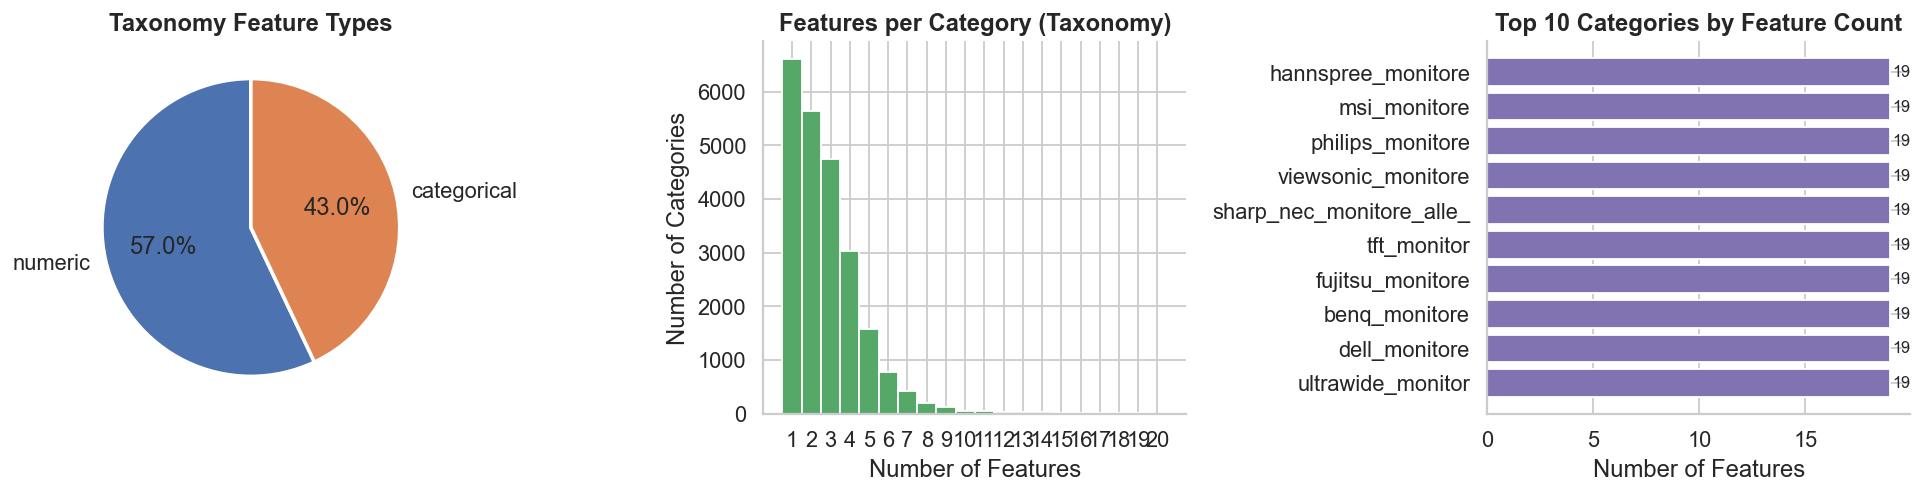

In [8]:
# Feature type split in taxonomy
feat_type_counts = taxonomy['feature_type'].value_counts()

# Features per category
feats_per_cat = taxonomy.groupby('category')['feature_name'].count()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pie chart
axes[0].pie(feat_type_counts.values, labels=feat_type_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'], wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Taxonomy Feature Types', fontweight='bold')

# Features per category histogram
axes[1].hist(feats_per_cat.values, bins=range(1, 22), color='#55A868', edgecolor='white', align='left')
axes[1].set_title('Features per Category (Taxonomy)', fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Number of Categories')
axes[1].set_xticks(range(1, 21))

# Top categories with most features
top_feat_cats = feats_per_cat.sort_values(ascending=False).head(10)
axes[2].barh(top_feat_cats.index[::-1], top_feat_cats.values[::-1], color='#8172B2', edgecolor='white')
axes[2].set_title('Top 10 Categories by Feature Count', fontweight='bold')
axes[2].set_xlabel('Number of Features')
for i, v in enumerate(top_feat_cats.values[::-1]):
    axes[2].text(v + 0.1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

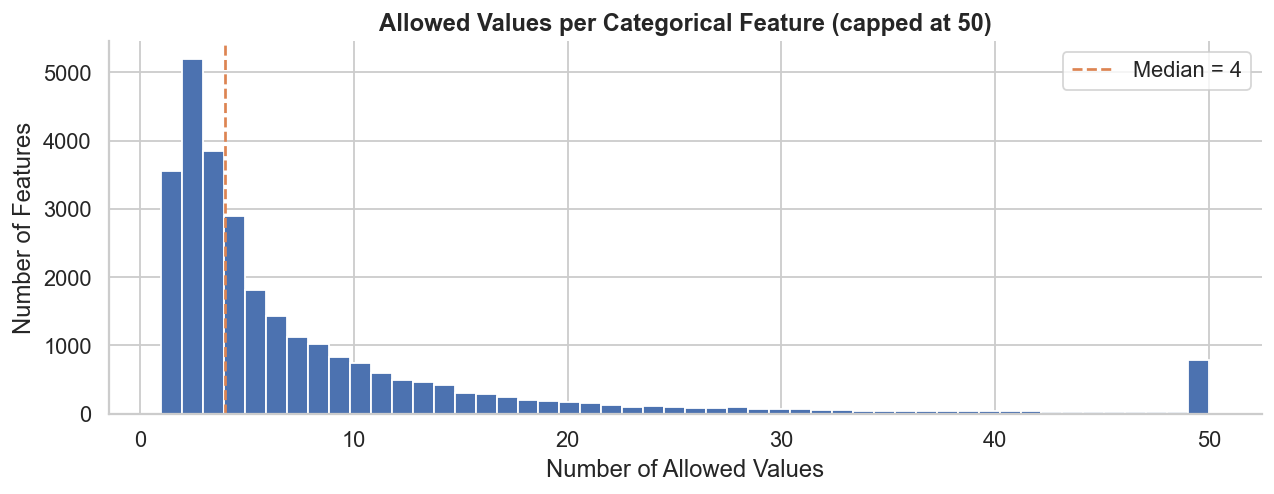

Median allowed values per categorical feature: 4
Mean: 12.5 | Max: 20411


In [9]:
# Allowed values per categorical feature
def count_values(s):
    if pd.isna(s) or str(s) == 'nan':
        return 0
    return len(re.findall(r"'\[.*?\]'", str(s)))

cat_tax = taxonomy[taxonomy['feature_type'] == 'categorical'].copy()
cat_tax['n_values'] = cat_tax['aggregated_feature_values'].apply(count_values)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cat_tax['n_values'].clip(upper=50), bins=50, color='#4C72B0', edgecolor='white')
ax.set_title('Allowed Values per Categorical Feature (capped at 50)', fontweight='bold')
ax.set_xlabel('Number of Allowed Values')
ax.set_ylabel('Number of Features')
ax.axvline(cat_tax['n_values'].median(), color='#DD8452', linestyle='--', linewidth=1.5,
           label=f'Median = {cat_tax["n_values"].median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median allowed values per categorical feature: {cat_tax["n_values"].median():.0f}')
print(f'Mean: {cat_tax["n_values"].mean():.1f} | Max: {cat_tax["n_values"].max()}')

## 6. Feature Label Analysis (Train)

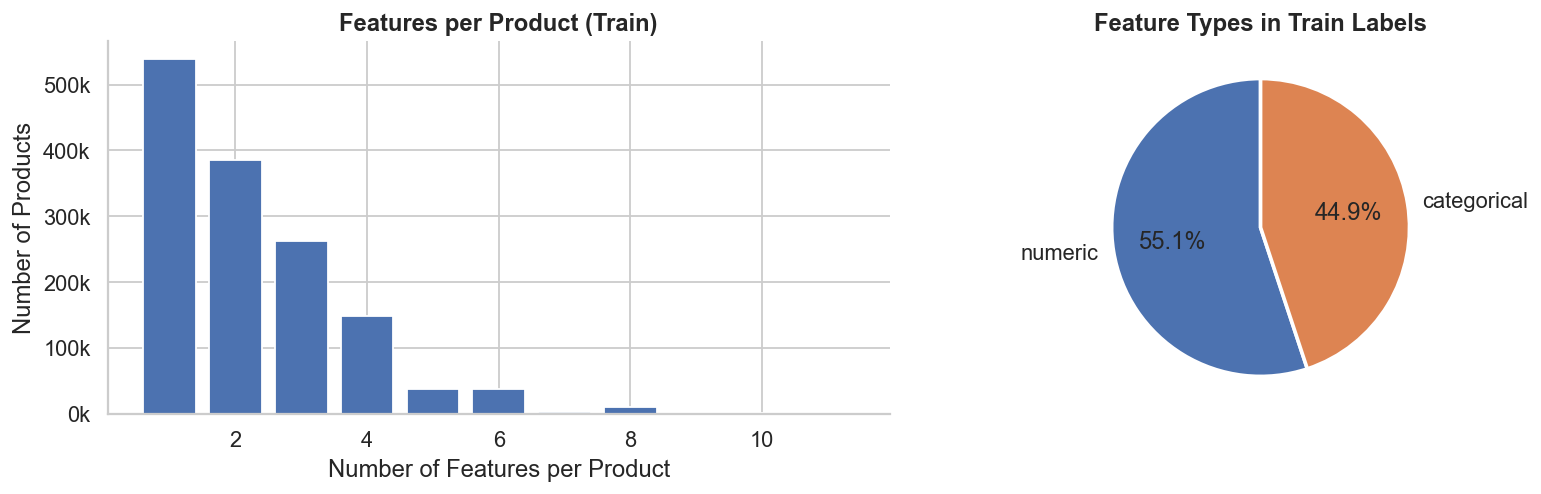

Avg features per product: 2.26
Median: 2 | Max: 11


In [10]:
# Features per product distribution
feats_per_prod = train_features.groupby('uid')['feature_name'].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

val_counts = feats_per_prod.value_counts().sort_index()
axes[0].bar(val_counts.index, val_counts.values, color='#4C72B0', edgecolor='white')
axes[0].set_title('Features per Product (Train)', fontweight='bold')
axes[0].set_xlabel('Number of Features per Product')
axes[0].set_ylabel('Number of Products')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))

# Feature type split in labels
label_type_counts = train_features['feature_type'].value_counts()
axes[1].pie(label_type_counts.values, labels=label_type_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'], wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Feature Types in Train Labels', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Avg features per product: {feats_per_prod.mean():.2f}')
print(f'Median: {feats_per_prod.median():.0f} | Max: {feats_per_prod.max()}')

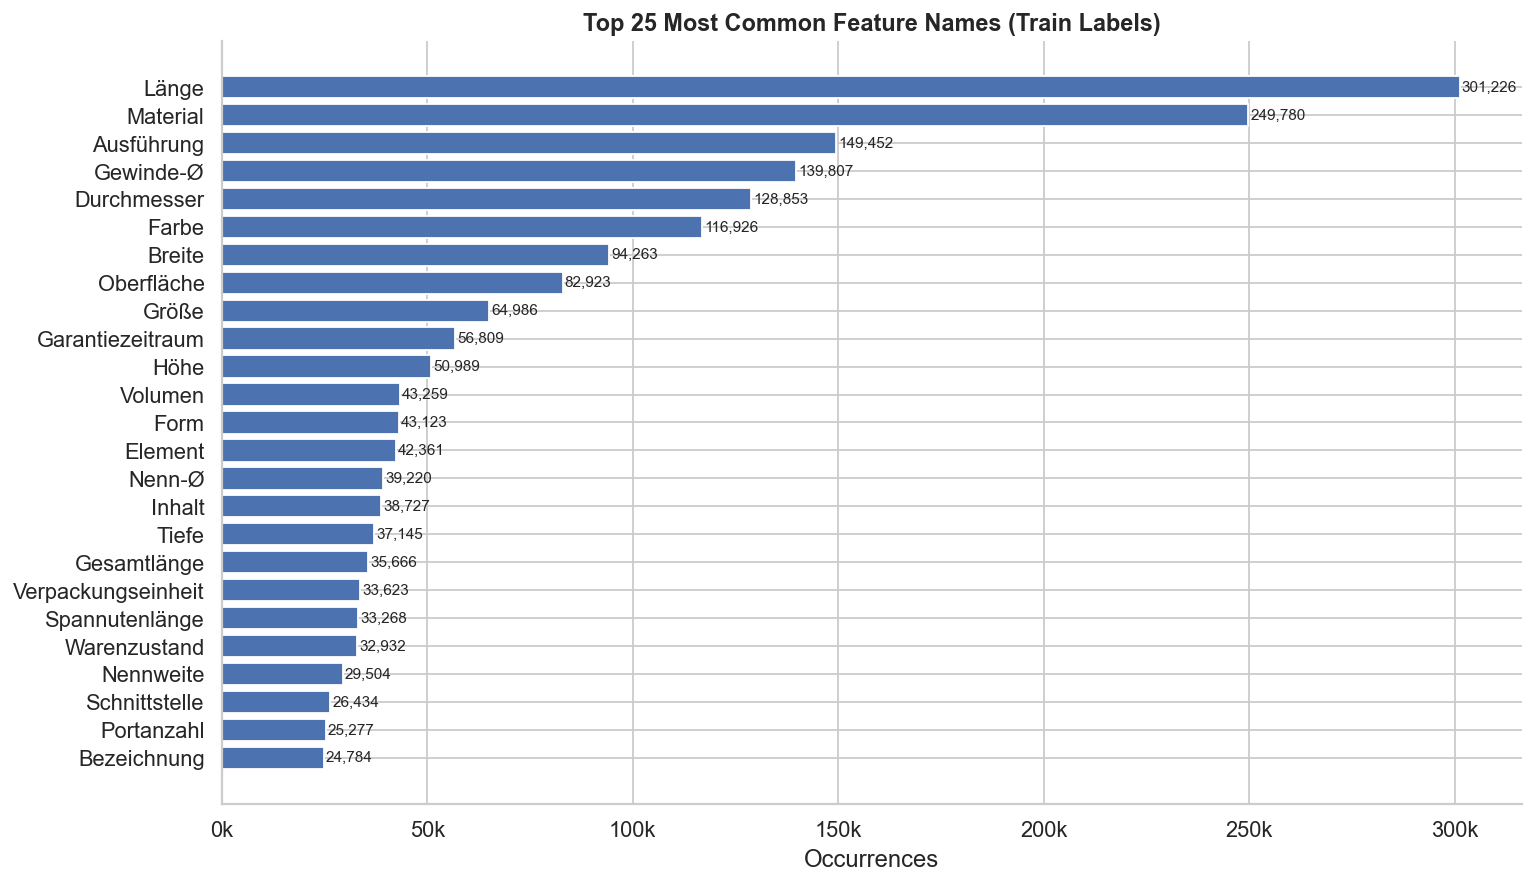

In [11]:
# Top 25 most common feature names in train labels
top_feat_names = train_features['feature_name'].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_feat_names.index[::-1], top_feat_names.values[::-1], color='#4C72B0', edgecolor='white')
ax.set_title('Top 25 Most Common Feature Names (Train Labels)', fontweight='bold', fontsize=13)
ax.set_xlabel('Occurrences')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
for bar, n in zip(bars, top_feat_names.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{n:,}', va='center', fontsize=8.5)
plt.tight_layout()
plt.show()

## 7. Top Feature Value Distributions (Categorical)

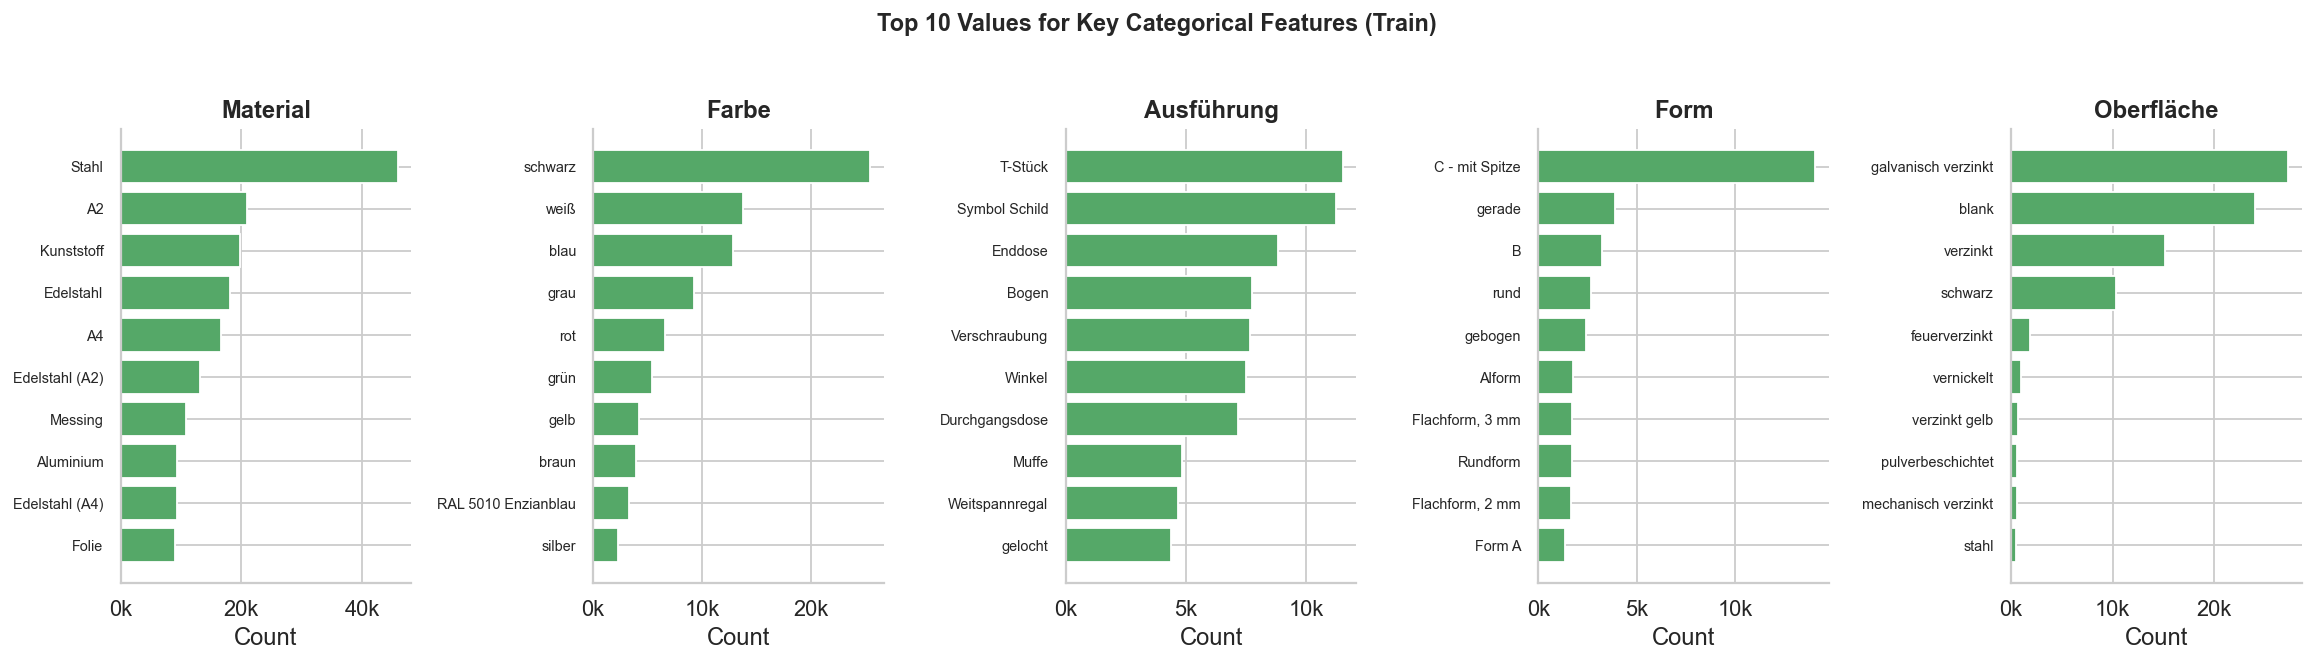

In [12]:
cat_features = train_features[train_features['feature_type'] == 'categorical']
top_features = ['Material', 'Farbe', 'Ausführung', 'Form', 'Oberfläche']

fig, axes = plt.subplots(1, len(top_features), figsize=(18, 5))

for ax, fname in zip(axes, top_features):
    vals = cat_features[cat_features['feature_name'] == fname]['feature_value'].value_counts().head(10)
    ax.barh(vals.index[::-1], vals.values[::-1], color='#55A868', edgecolor='white')
    ax.set_title(fname, fontweight='bold')
    ax.set_xlabel('Count')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 10 Values for Key Categorical Features (Train)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 8. Text Length Analysis

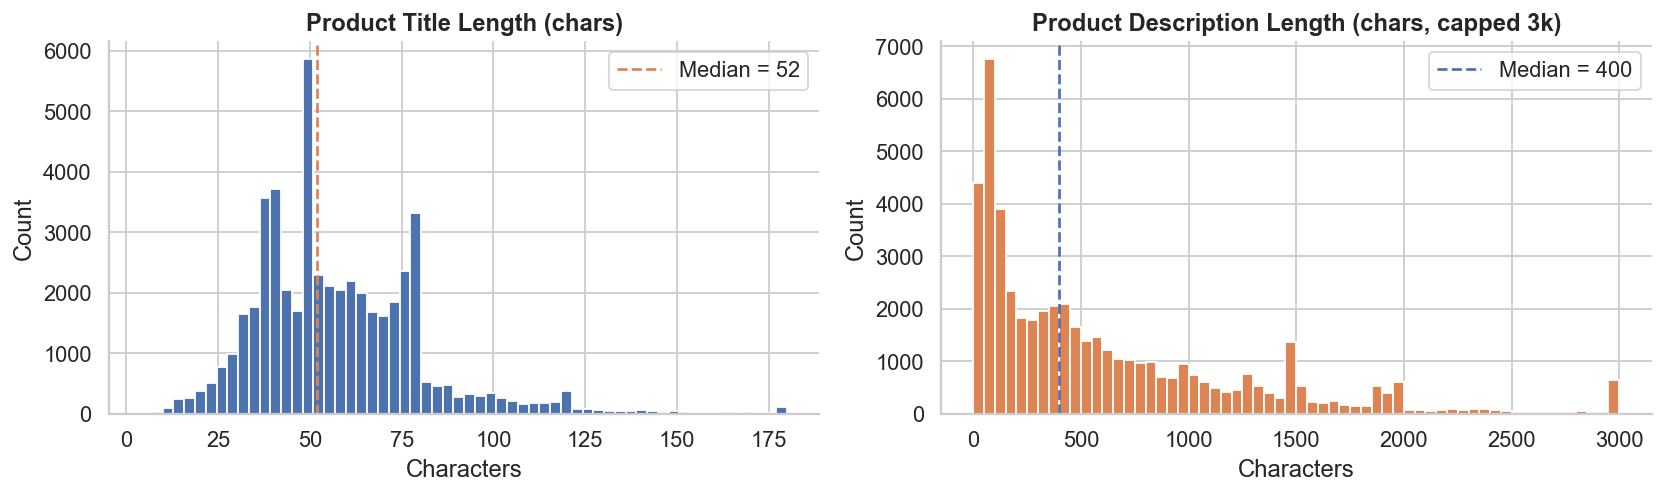

Title  — mean: 58  median: 52  p99: 134
Desc   — mean: 626  median: 400  p99: 3173


In [13]:
sample = train_products.sample(50_000, random_state=42).copy()
sample['title_len'] = sample['title'].fillna('').str.len()
sample['desc_len']  = sample['description'].fillna('').apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sample['title_len'].clip(upper=300), bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_title('Product Title Length (chars)', fontweight='bold')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Count')
axes[0].axvline(sample['title_len'].median(), color='#DD8452', linestyle='--',
                label=f'Median = {sample["title_len"].median():.0f}')
axes[0].legend()

axes[1].hist(sample['desc_len'].clip(upper=3000), bins=60, color='#DD8452', edgecolor='white')
axes[1].set_title('Product Description Length (chars, capped 3k)', fontweight='bold')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')
axes[1].axvline(sample['desc_len'].median(), color='#4C72B0', linestyle='--',
                label=f'Median = {sample["desc_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Title  — mean: {sample["title_len"].mean():.0f}  median: {sample["title_len"].median():.0f}  p99: {sample["title_len"].quantile(0.99):.0f}')
print(f'Desc   — mean: {sample["desc_len"].mean():.0f}  median: {sample["desc_len"].median():.0f}  p99: {sample["desc_len"].quantile(0.99):.0f}')

## 9. Submission Template Inspection

In [14]:
print('Submission shape:', submission.shape)
print('Null feature_value:', submission['feature_value'].isna().sum(), '/', len(submission))
print()
print('Sample rows:')
submission.head(10)

Submission shape: (7864744, 4)
Null feature_value: 7864744 / 7864744

Sample rows:


,uid,feature_name,feature_value,feature_type
0,B7299-499409-BP_|_schwingschleifblatt,Ausführung,None,categorical
1,B5585-2170327-BP_|_apparaterolle,Laufbelag,None,categorical
2,PNJMV-828493-MU_|_bit_phillips,Antrieb,None,categorical
3,PNJMV-2611847-MU_|_torx_bit_satz,Anzahl Teile,None,numeric
4,BH9F9-826149_|_magazinschrank,Farbe,None,categorical
5,B3818-0325090_|_multispray,Inhalt,None,numeric
7,B6951-1066177-BP_|_iso7046_edelstahl,Länge,None,numeric
12,B6314-3330261-BP_|_bohrerbit,Gesamtlänge,None,numeric
13,B7660-2247880-BP_|_modellbau_spruehfarben,Farbe,None,categorical
16,B3626-1792912-BP_|_iso8744,Durchmesser,None,numeric


## 10. Sample Products with Labels (Train)

In [15]:
# Show a few complete product + feature examples
sample_uids = train_features.groupby('uid').filter(lambda x: len(x) >= 3)['uid'].drop_duplicates().head(3)

for uid in sample_uids:
    row = train_products[train_products['uid'] == uid].iloc[0]
    feats = train_features[train_features['uid'] == uid]
    print(f'UID:      {uid}')
    print(f'Category: {row["category"]}')
    print(f'Title:    {row["title"][:120]}')
    print(f'Desc:     {str(row["description"])[:200]}...')
    print('Features:')
    print(feats[['feature_name','feature_value','feature_type']].to_string(index=False))
    print('-' * 80)

UID:      B2887-228998_|_sicherheitsascher
Category: sicherheitsascher
Title:    Kombiascher, HxØ 800x310mm, 40l, Korpus Stahl weiß, Löschkopf
Desc:     Kombination aus Ascher und Abfallbehälter. Der Behälter ist aus beschichtetem Stahlblech. Die besondere Deckelkonstruktion verhindert einen permanenten Sauerstoffaustausch, so dass Feuer und Glut gelö...
Features:
feature_name feature_value feature_type
    Material         Stahl  categorical
    Breite/Ø        310 mm      numeric
       Farbe          weiß  categorical
     Volumen          40 l      numeric
--------------------------------------------------------------------------------
UID:      B4100-1783876_|_pozidrivschraubendreher
Category: pozidrivschraubendreher
Title:    Kreuzschlitzdreher PZ FL 1 SLIM 117780
Desc:     Schraubsystem Pozidriv PZ, Größe 1, Ausführung gerade, Klingenlänge 100mm, Gesamtlänge 185mm, Klingendurchmesser 3mm, Isoliert, Schutzisoliert 1000 V, Werkstoff des Griffs Kunststoff, Griffausführung ...
Featu